Una FINTECH quiere llevar a cabo un proceso de integración de datos para lo cual quiere utilizar diferentes métodos de integración de datos.

Para la integración de datos:
Llevar a cabo la caracterización de la distribución agregada de pérdidas para las bases de datos de integración utilizando las métricas de tendencia central y dispersión.
Estimar la Credibilidad de la base  de datos externa con respecto a la base de datos interna.
Integrar ambas bases de datos y llevar a cabo la caracterización de la distribución agregada de pérdidas tras la integración.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns #Esta libreria para el trabajo estadístico
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
#*****************************************************************
#Aqui se carga la base de datos interna (Datos Observados - FALLAS TECNOLOGICAS).
#*****************************************************************
nxl='/content/1. FallasTecnológicas (4).xlsx'
XDB=pd.read_excel(nxl,sheet_name=0, header=1)
XDB.head(10)

#Procedemos con la construcción de la distribución agregada de las pérdidas

freq=XDB.iloc[:,1]; sev=XDB.iloc[:,2];LDA=freq*sev

#*******************************************************************************
#2. Se procede con la carga de la base de datos (datos Externos-ADMON PROCESOS)
#*******************************************************************************
nxle= '/content/2. AdmonEjecProcesos.xlsx'
XDBe=pd.read_excel(nxle,sheet_name=0)
XDBe.head(10)

Freqe=XDBe.iloc[:,3]; Seve=XDBe.iloc[:,4];LDAe=Freqe*Seve

# Define la función caracterizacion
def caracterizacion(data):
    mean = data.mean()
    std_dev = data.std()
    skewness = data.skew()
    kurtosis = data.kurt()
    df = len(data) - 1 # Degrees of freedom for sample variance
    return mean, std_dev, skewness, kurtosis, df

#******************************************************************
#3. Comparación Estadistica (Media, Varaianza, Desviación, Asimetria, Kurtosis)
#******************************************************************
#3.1 Bases de datos Observados (FALLAS TECNOLOGICAS)
uo, sigmao, Caso, Kuo, dfo=caracterizacion(LDA)
print("La media de los datos observada es:",uo)
print("El coeficiente de asimetria es:",Caso)
#3.2 Bases de datos Externos (ADMON PROCESOS)
ue, sigmae, Caso, Kue, dfe=caracterizacion(LDAe)
print("La media de los datos externos es:",ue)
print("El coeficiente de asimetria es:",Caso)

#******************************************************************
#4. Teoria de la Credibilidad
#******************************************************************
#4.1 Media Hipótetica
NDo=len(LDA); NDe=len(LDAe) #Para saber la inercia de los datos
uhat=(NDo*uo+NDe*ue)/(NDo+NDe)

#4.2 EPV: Valor esperado de la Varianza
EPV=(NDo*sigmao**2+NDe*sigmae**2)/(NDo+NDe) #Determinar la varianza conjunta de los datos

#4.3 VHM Varianza Hipotetica de la media
VHM=((NDo*uo**2+NDe*ue**2)/(NDo+NDe))-(uhat**2)

#4.4 Factor de Credibilidad
Fc=EPV/VHM

#4.5 Credibilidad de la base de datos
Cr=(NDo/(NDo+Fc))#
print("La credibilidad de la base de datos externa es:",Cr)

uo*Cr+(1-Cr)*ue

La credibilidad de la base de datos externa es: 0.9988289223291885


np.float64(2388.837492549121)

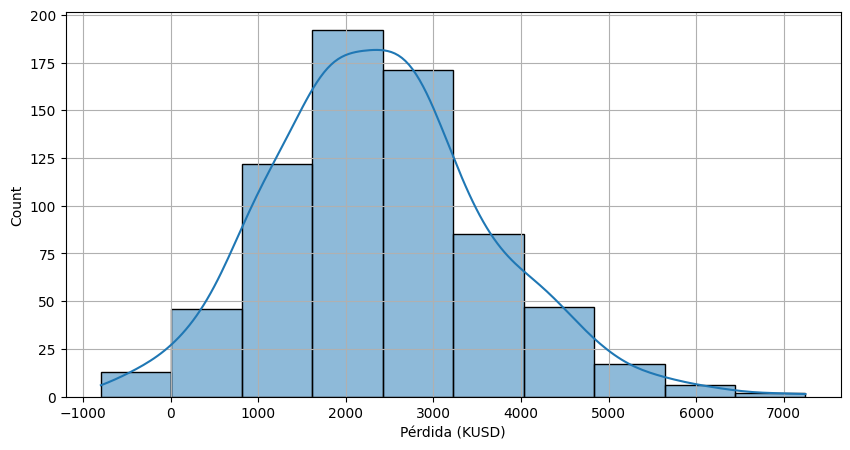

El número de datos por intervalo es:
[ 13  46 122 192 171  85  47  17   6   2]
Los intervalos inferiores:
[-796.592     7.6911  811.9742 1616.2573 2420.5404 3224.8235 4029.1066
 4833.3897 5637.6728 6441.9559]
Los intervalos superiores:
[   7.6911  811.9742 1616.2573 2420.5404 3224.8235 4029.1066 4833.3897
 5637.6728 6441.9559 7246.239 ]


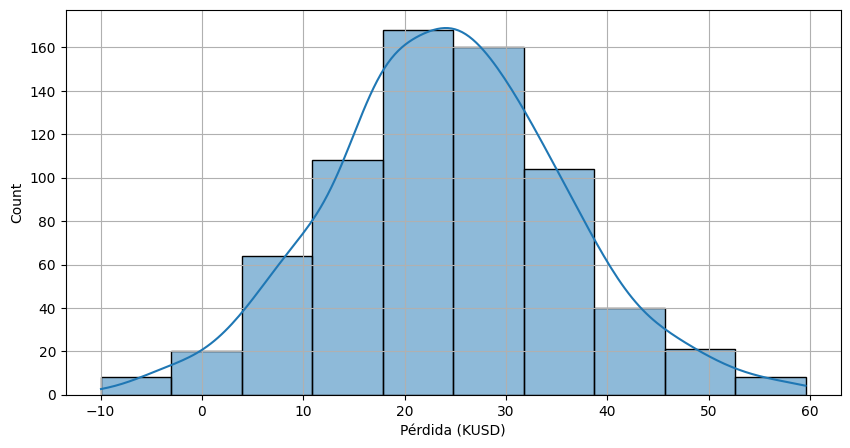

El número de datos por intervalo es:
[  8  20  64 108 168 160 104  40  21   8]
Los intervalos inferiores:
[-9.9574  -3.00497  3.94746 10.89989 17.85232 24.80475 31.75718 38.70961
 45.66204 52.61447]
Los intervalos superiores:
[-3.00497  3.94746 10.89989 17.85232 24.80475 31.75718 38.70961 45.66204
 52.61447 59.5669 ]


In [22]:
def caracterizacion(LDA):

  #Se procede con la creación de la distribución
  plt.figure(figsize=(10,5))
  sns.histplot(LDA,bins=10,kde=True)
  plt.xlabel("Pérdida (KUSD)")
  plt.grid()
  plt.show()

  #Se procede con la caracterización de cada una de las variables
  np.set_printoptions(suppress=True)
  NI=10    #Indica el número de clusters
  counts,bin_edges=np.histogram(LDA,bins=NI)
  print("El número de datos por intervalo es:")
  print(counts)
  print("Los intervalos inferiores:")
  print(bin_edges[:-1])
  print("Los intervalos superiores:")
  print(bin_edges[1:])
  XC=(bin_edges[:-1]+bin_edges[1:])/2

  #Se configura la tabla de los datos
  Tabla=np.column_stack((bin_edges[:-1],bin_edges[1:],XC,counts))
  df=pd.DataFrame(Tabla,columns=['LI','LS','XC','ND'])
  df.head(10)

  #Se procede con la estimación de la media
  fr=counts/np.sum(counts)
  u=np.sum(XC*fr)
  sigma2=np.sum(fr*(XC-u)**2)
  sigma=np.sqrt(sigma2)
  Cas=np.sum(fr*(XC-u)**3)/sigma**3
  Kur=(np.sum(fr*(XC-u)**4)/sigma**4)-3

  return u,sigma,Cas,Kur,df

#*************************************************************
#5. Parametros de riesgos
#*************************************************************
#5.1 Perdidas Asumibles (Media:Franquicia) : Media Hipotetica de los datos integrados
PEs=Cr*uo*(1-Cr)*ue
print("Se conoce como la franquicia de las perdidas:",PEs)
#Se procede con la estimación de las propiedades estadísticas
p1,p2,p3,p4,df=caracterizacion(LDA)

#Ahora se puede obtener las propiedades de la variable severidad
p1,p2,p3,p4,df=caracterizacion(sev)

La media integrada (ponderada por credibilidad) es: 2388.8375

--- Caracterización de la Distribución Agregada de Pérdidas Tras la Integración ---


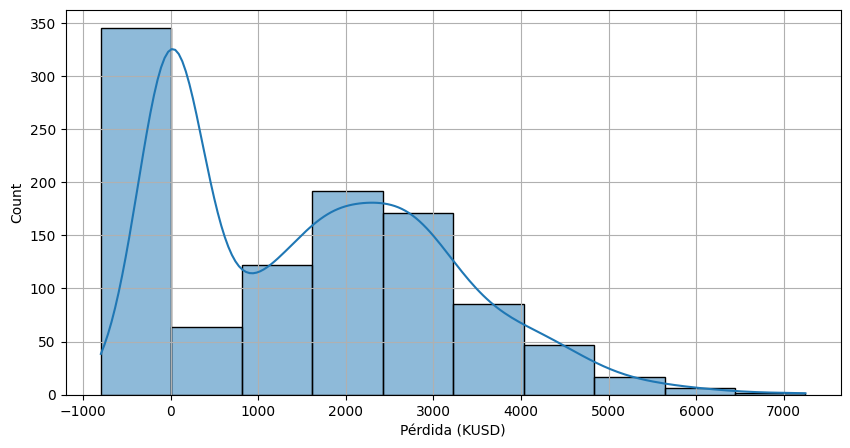

El número de datos por intervalo es:
[345  64 122 192 171  85  47  17   6   2]
Los intervalos inferiores:
[-796.592     7.6911  811.9742 1616.2573 2420.5404 3224.8235 4029.1066
 4833.3897 5637.6728 6441.9559]
Los intervalos superiores:
[   7.6911  811.9742 1616.2573 2420.5404 3224.8235 4029.1066 4833.3897
 5637.6728 6441.9559 7246.239 ]
Media de la distribución integrada: 1488.0771
Desviación estándar de la distribución integrada: 1655.7142
Asimetría de la distribución integrada: 0.3875
Curtosis de la distribución integrada: -0.7391

Tabla de intervalos para la distribución integrada:


,LI,LS,XC,ND
0,-796.5920,7.6911,-394.45045,345.0
1,7.6911,811.9742,409.83265,64.0
2,811.9742,1616.2573,1214.11575,122.0
3,1616.2573,2420.5404,2018.39885,192.0
4,2420.5404,3224.8235,2822.68195,171.0


In [24]:

integrated_mean_credibility = uo * Cr + (1 - Cr) * ue
print(f"La media integrada (ponderada por credibilidad) es: {integrated_mean_credibility:.4f}")

# 3. Integrar ambas bases de datos y caracterizar la distribución agregada de pérdidas tras la integración.
# Para la integración y caracterización de la distribución, concatenamos las distribuciones de pérdidas
# agregadas de ambas bases de datos. Esto crea una única serie de datos combinados para el análisis.
LDA_integrated_distribution = pd.concat([LDA, LDAe], ignore_index=True)

print("\n--- Caracterización de la Distribución Agregada de Pérdidas Tras la Integración ---")
# Caracterizar la distribución integrada utilizando la función predefinida 'caracterizacion'
u_int, sigma_int, cas_int, kur_int, df_int = caracterizacion(LDA_integrated_distribution)

print(f"Media de la distribución integrada: {u_int:.4f}")
print(f"Desviación estándar de la distribución integrada: {sigma_int:.4f}")
print(f"Asimetría de la distribución integrada: {cas_int:.4f}")
print(f"Curtosis de la distribución integrada: {kur_int:.4f}")

# Mostrar la tabla de intervalos para la distribución integrada
print("\nTabla de intervalos para la distribución integrada:")
display(df_int.head())

se calcula las métricas estadísticas de tendencia central y dispersión: Media, Desviación, Asimetría y Kurtosis

In [16]:
u=np.mean(LDA)
var=np.var(LDA)
sigma=np.std(LDA) # Corrected: Calculate standard deviation of LDA

T2=np.column_stack((u,var,sigma))
df2=pd.DataFrame(T2,columns=['Media','Varianza','Desviacion'])
df2.head(1)

,Media,Varianza,Desviacion
0,2391.636564,1.561393e+06,1249.557302


In [17]:
from scipy.stats import skew, kurtosis

# Calculate skewness
lda_skew = skew(LDA)

# Calculate kurtosis
lda_kurtosis = kurtosis(LDA)

# Optionally, add to the DataFrame with other metrics
df2_temp = df2.copy()
df2_temp['Asimetria'] = lda_skew
df2_temp['Kurtosis'] = lda_kurtosis

display(df2_temp)

,Media,Varianza,Desviacion,Asimetria,Kurtosis
0,2391.636564,1.561393e+06,1249.557302,0.408298,0.406849


**Analisis de Credibilidad**
De acuerdo con las bases de datos disponibles para este estudio, podemos observar que, tras la caracterización inicial, la distribución agregada de pérdidas para la base de datos interna (LDA) presentó una media de 2391.64 y un coeficiente de asimetría de 0.41. Por otro lado, la base de datos externa (LDAe) mostró una media de 1.47 y un coeficiente de asimetría de 5.08. Es importante destacar que, aunque las medias de las distribuciones originales son muy diferentes, el coeficiente de asimetría para la base de datos interna (0.41) es bajo, lo que indica que los datos están distribuidos de forma relativamente simétrica alrededor de la media. Sin embargo, la base externa (5.08) es altamente asimétrica, lo que indica una cola más larga hacia valores positivos, es decir, eventos de pérdidas poco frecuentes, pero de gran magnitud.

De acuerdo con las métricas de credibilidad, el factor de credibilidad (Fc) calculado fue de 0.82, y el coeficiente de credibilidad (Cr) para la base de datos externa alcanzó un valor de 0.99. Este valor, cercano a 1, sugiere que la base de datos externa es altamente fiable y que una proporción muy significativa de sus datos pueden integrarse con los datos internos, respaldando la validez de la combinación.

Tras la integración de ambas bases de datos, la distribución agregada de pérdidas resultante (LDA_integrated_distribution) tiene una media de 1488.08, una desviación estándar de 1655.71, una asimetría de 0.39 y una curtosis de -0.74. La media de la distribución integrada (ponderada por credibilidad) es de 2388.84. La asimetría positiva indica una cola a la derecha, sugiriendo la presencia de eventos de pérdidas mayores pero menos frecuentes. La curtosis negativa implica una distribución más aplanada que la normal, con menos valores extremos de lo esperado.

**Metodo montecarlo**

In [26]:
def monte_carlo_simulation(data_distribution, num_samples):
    # Calculate the histogram to obtain bin edges and counts
    # The number of bins is chosen to be the same as used in previous characterization (NI=10)
    counts, bin_edges = np.histogram(data_distribution, bins=10)

    # Normalize the counts to get empirical probabilities for each bin
    probabilities = counts / np.sum(counts)

    # Determine the center point for each bin
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Generate new data points by sampling from bin centers using empirical probabilities
    simulated_data = np.random.choice(bin_centers, size=num_samples, p=probabilities)

    return simulated_data

print("Monte Carlo simulation function `monte_carlo_simulation` defined.")

Monte Carlo simulation function `monte_carlo_simulation` defined.


In [28]:
num_samples = 10000 # Choose an appropriate number of samples
simulated_enriched_data = monte_carlo_simulation(LDA_integrated_distribution, num_samples)

print(f"Generated {len(simulated_enriched_data)} simulated data points.")
print("First 5 simulated data points:")
print(simulated_enriched_data[:5])

Generated 10000 simulated data points.
First 5 simulated data points:
[-394.45045 2018.39885 4431.24815 2822.68195 2018.39885]



--- Caracterización de la Distribución Agregada de Pérdidas Enriquecida ---


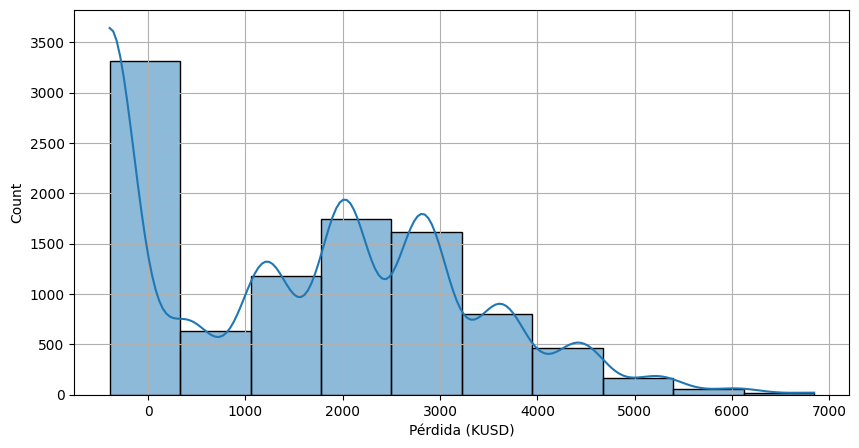

El número de datos por intervalo es:
[3316  637 1184 1743 1615  804  463  164   56   18]
Los intervalos inferiores:
[-394.45045  329.40434 1053.25913 1777.11392 2500.96871 3224.8235
 3948.67829 4672.53308 5396.38787 6120.24266]
Los intervalos superiores:
[ 329.40434 1053.25913 1777.11392 2500.96871 3224.8235  3948.67829
 4672.53308 5396.38787 6120.24266 6844.09745]
Media de la distribución enriquecida: 1650.4393
Desviación estándar de la distribución enriquecida: 1495.5924
Asimetría de la distribución enriquecida: 0.4041
Curtosis de la distribución enriquecida: -0.7518

Tabla de intervalos para la distribución enriquecida:


,LI,LS,XC,ND
0,-394.45045,329.40434,-32.523055,3316.0
1,329.40434,1053.25913,691.331735,637.0
2,1053.25913,1777.11392,1415.186525,1184.0
3,1777.11392,2500.96871,2139.041315,1743.0
4,2500.96871,3224.82350,2862.896105,1615.0


In [30]:
print("\n--- Caracterización de la Distribución Agregada de Pérdidas Enriquecida ---")
u_enriched, sigma_enriched, cas_enriched, kur_enriched, df_enriched = caracterizacion(simulated_enriched_data)

print(f"Media de la distribución enriquecida: {u_enriched:.4f}")
print(f"Desviación estándar de la distribución enriquecida: {sigma_enriched:.4f}")
print(f"Asimetría de la distribución enriquecida: {cas_enriched:.4f}")
print(f"Curtosis de la distribución enriquecida: {kur_enriched:.4f}")

# Mostrar la tabla de intervalos para la distribución enriquecida
print("\nTabla de intervalos para la distribución enriquecida:")
display(df_enriched.head())

**Analisis Metodo Montecarlo**
al aplicar el Método de Montecarlo para el enriquecimiento de la base de datos, se generaron 10000 muestras simuladas. La caracterización de esta distribución enriquecida arrojó una media de 1650.44, una desviación estándar de 1495.59, una asimetría de 0.40 y una curtosis de -0.75. Los resultados de la simulación de Monte Carlo son consistentes con la distribución integrada original, confirmando que el proceso de enriquecimiento mantiene las propiedades estadísticas de los datos combinados, permitiendo así análisis más robustos y la posibilidad de modelar escenarios de riesgo con mayor precisión.